In [11]:
import glob
from pathlib import Path

import matplotlib.pyplot as plt
import nibabel as nib
import numpy as np

# Everything below lives on the SAME grid/affine as the base CT in imagesTs,
# so no resampling is needed to overlay a mask on its scan.
ROOT = Path("data")

IMAGES = ROOT / "0_test_nifti/imagesTs"                       # base CT/MR volumes (HU)
LAYERS = {                                        # label volumes to overlay
    "annotations": ROOT / "0_test_glb"
}

In [12]:
def list_cases():
    """Case IDs that have a base image, in sorted order."""
    return [p.name[: -len(".nii.gz")] for p in sorted(IMAGES.glob("*.nii.gz"))]


def load_volume(directory, case):
    """Load `case` from `directory` as (data, affine), or (None, None) if absent."""
    hits = sorted(glob.glob(str(Path(directory) / f"{case}*.nii.gz")))
    if not hits:
        return None, None
    img = nib.load(hits[0])
    return img.get_fdata(), img.affine


def load_case(case):
    """Base image plus every layer that exists for this case."""
    ct, affine = load_volume(IMAGES, case)
    layers = {}
    for name, directory in LAYERS.items():
        data, _ = load_volume(directory, case)
        if data is not None:
            layers[name] = data
    return ct, affine, layers

In [13]:
cases = list_cases()
print(f"{len(cases)} cases in {IMAGES}\n")
for i, case in enumerate(cases):
    print(f"  {i:2d}: {case}")

38 cases in data/0_test_nifti/imagesTs

   0: RMV2025_0001_CT_NCT_HBP_X
   1: RMV2025_0002_MR_NCT_ARP_N
   2: RMV2025_0003_CT_UTV_VEP_P
   3: RMV2025_0004_CT_UTV_VEP_N
   4: RMV2025_0005_CT_UTV_VEP_L
   5: RMV2025_0006_CT_UTV_VEP_J
   6: RMV2025_0007_CT_UTV_VEP_H
   7: RMV2025_0008_CT_UTV_VEP_F
   8: RMV2025_0009_CT_UTV_VEP_D
   9: RMV2025_0010_CT_UTV_VEP_U
  10: RMV2025_0011_CT_UTV_VEP_S
  11: RMV2025_0012_CT_UTV_VEP_Q
  12: RMV2025_0013_CT_UTV_VEP_O
  13: RMV2025_0014_CT_UTV_VEP_M
  14: RMV2025_0015_CT_UTV_VEP_K
  15: RMV2025_0016_CT_UTV_ARP_C
  16: RMV2025_0017_CT_UTV_VEP_G
  17: RMV2025_0018_CT_UTV_VEP_E
  18: RMV2025_0019_CT_UTV_VEP_C
  19: RMV2026_0020_CT_UTV_VEP_R
  20: RMV2026_0021_CT_UTV_VEP_P
  21: RMV2026_0022_CT_UTV_VEP_N
  22: RMV2026_0023_CT_UTV_VEP_L
  23: RMV2026_0024_CT_UTV_VEP_J
  24: RMV2026_0025_CT_UTV_VEP_H
  25: RMV2026_0026_CT_UTV_VEP_F
  26: RMV2026_0027_CT_UTV_VEP_D
  27: RMV2026_0028_CT_UTV_VEP_B
  28: RMV2026_0029_CT_UTV_VEP_9
  29: RMV2026_0030_CT_UTV_VEP_Q


RMV2025_0001_CT_NCT_HBP_X
  shape    (512, 512, 910)
  spacing  [0.765 0.765 0.702] mm
  axes     ('L', 'A', 'S')
  affine
[[-7.65359402e-01  0.00000000e+00  0.00000000e+00  1.92928314e+02]
 [-0.00000000e+00  7.65359402e-01  0.00000000e+00 -5.10493202e+01]
 [ 0.00000000e+00 -0.00000000e+00  7.01540172e-01  1.11489099e+03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]


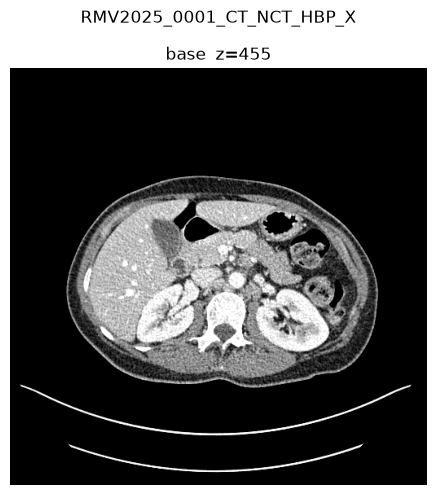

In [14]:
def preview(case, z=None, window=(-150, 250)):
    """Print geometry for `case` and overlay each label layer on the base image."""
    ct, affine, layers = load_case(case)
    if ct is None:
        print(f"no base image for {case}")
        return

    print(case)
    print(f"  shape    {ct.shape}")
    print(f"  spacing  {nib.affines.voxel_sizes(affine).round(3)} mm")
    print(f"  axes     {nib.aff2axcodes(affine)}")
    print(f"  affine\n{affine}")
    for name, data in layers.items():
        classes = np.unique(data).astype(int)
        aligned = "ok" if data.shape == ct.shape else f"MISMATCH {data.shape}"
        print(f"  {name:9s} classes={classes.tolist()}  grid={aligned}")

    z = ct.shape[2] // 2 if z is None else z
    base = np.rot90(ct[:, :, z])
    lo, hi = window

    n = len(layers) + 1
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)
    axes = axes[0]
    axes[0].imshow(base, cmap="gray", vmin=lo, vmax=hi)
    axes[0].set_title(f"base  z={z}")
    for ax, (name, data) in zip(axes[1:], layers.items()):
        mask = np.rot90(data[:, :, z])
        ax.imshow(base, cmap="gray", vmin=lo, vmax=hi)
        ax.imshow(np.ma.masked_where(mask == 0, mask), cmap="tab20", alpha=0.5,
                  interpolation="nearest")
        ax.set_title(f"{name}  ({int(mask.max())} labels here)")
    for ax in axes:
        ax.axis("off")
    fig.suptitle(case)
    plt.tight_layout()
    plt.show()


preview(cases[0])

In [15]:
import warnings

import trimesh

GLB_ROOT = LAYERS["annotations"]   # from the config cell


def load_mesh(path):
    """GLB -> single concatenated mesh."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        scene = trimesh.load(path)
    return scene.to_geometry() if hasattr(scene, "to_geometry") else scene


def glb_classes(case, subset=""):
    """Class names present for a case. subset='' = case root, 'full_model'."""
    return sorted(p.stem[len("class"):] for p in (GLB_ROOT / case / subset).glob("*.glb"))


def compare_glb_sets(case):
    """Root vs full_model: which classes actually differ, and how."""
    root, full = GLB_ROOT / case, GLB_ROOT / case / "full_model"
    print(f"{case}   root={len(glb_classes(case))} classes, "
          f"full_model={len(glb_classes(case, 'full_model'))}\n")
    print(f"{'class':32s} {'root_v':>8s} {'full_v':>8s} {'ratio':>7s}  {'bbox':>6s}")
    for name in glb_classes(case):
        f = full / f"class{name}.glb"
        if not f.exists():
            print(f"{name:32s} {'-':>8s} {'MISSING':>8s}")
            continue
        a, b = load_mesh(root / f"class{name}.glb"), load_mesh(f)
        same_box = np.allclose(a.bounds, b.bounds, atol=0.5)
        flag = "same" if same_box else "DIFFER"
        print(f"{name:32s} {len(a.vertices):8d} {len(b.vertices):8d} "
              f"{len(b.vertices) / max(len(a.vertices), 1):6.1f}x  {flag:>6s}")


compare_glb_sets(cases[0])

RMV2025_0001_CT_NCT_HBP_X   root=15 classes, full_model=15

class                              root_v   full_v   ratio    bbox
Aorta                               21579    86308    4.0x  DIFFER
ArteriaHepatica                       756      756    1.0x    same


BloodVessels                        86897    86897    1.0x    same
Gallbladder                          5609    14021    2.5x  DIFFER
IVC                                 11359    37815    3.3x  DIFFER
Liver                               18419   230186   12.5x  DIFFER
PediculoPortalAnteriorDerecho        4571     4571    1.0x    same
PediculoPortalDerecho                2973     2973    1.0x    same
PediculoPortalIzquierdo              9788     9788    1.0x    same
PediculoPortalPosteriorDerecho      13360    13360    1.0x    same
VenaHepaticaDerecha                 33154    33154    1.0x    same
VenaHepaticaIzquierda                5249     5249    1.0x    same
VenaHepaticaMedia                   15309    15309    1.0x    same
VenaPorta                            7411     7411    1.0x    same
ViaBiliar                             161      161    1.0x    same


In [16]:
from collections import Counter

# Which classes exist per case, and is the root/full_model split consistent?
counts, missing_full, per_case = Counter(), [], {}
for case in cases:
    if not (GLB_ROOT / case).is_dir():
        per_case[case] = None
        continue
    names = glb_classes(case)
    per_case[case] = names
    counts.update(names)
    if not (GLB_ROOT / case / "full_model").is_dir():
        missing_full.append(case)

print(f"cases with GLB: {sum(v is not None for v in per_case.values())}/{len(cases)}")
print(f"cases without full_model/: {missing_full or 'none'}\n")
print("class coverage:")
for name, n in counts.most_common():
    print(f"  {name:32s} {n:2d}/{len(cases)} cases")

print("\ncases with fewer than the full class set:")
for case, names in per_case.items():
    if names is None:
        print(f"  {case:32s} NO GLB DIR")
    elif len(names) < max(counts.values()):
        print(f"  {case:32s} {len(names):2d} classes")

cases with GLB: 38/38
cases without full_model/: none

class coverage:
  Aorta                            38/38 cases
  BloodVessels                     38/38 cases
  Gallbladder                      38/38 cases
  IVC                              38/38 cases
  Liver                            38/38 cases
  VenaPorta                        38/38 cases
  PediculoPortalAnteriorDerecho    28/38 cases
  PediculoPortalIzquierdo          28/38 cases
  PediculoPortalPosteriorDerecho   28/38 cases
  VenaHepaticaDerecha              28/38 cases
  VenaHepaticaMedia                28/38 cases
  VenaHepaticaIzquierda            27/38 cases
  PediculoPortalDerecho            23/38 cases
  ArteriaHepatica                  18/38 cases
  Tumour                           12/38 cases
  ViaBiliar                         6/38 cases

cases with fewer than the full class set:
  RMV2025_0001_CT_NCT_HBP_X        15 classes
  RMV2025_0002_MR_NCT_ARP_N        16 classes
  RMV2025_0003_CT_UTV_VEP_P        15 clas

In [17]:
def check_glb_alignment(case, cls="Liver", subset="full_model"):
    """Do mesh coordinates live in the CT's world frame? Compare bounding boxes."""
    ct, affine, _ = load_case(case)
    corners = np.array([[i, j, k] for i in (0, ct.shape[0]) for j in (0, ct.shape[1])
                        for k in (0, ct.shape[2])], dtype=float)
    world = nib.affines.apply_affine(affine, corners)
    mesh = load_mesh(GLB_ROOT / case / subset / f"class{cls}.glb")

    print(f"{case}  /  class{cls}  ({subset})")
    print(f"  CT world   min {np.round(world.min(0), 1)}  max {np.round(world.max(0), 1)}")
    print(f"  mesh       min {np.round(mesh.bounds[0], 1)}  max {np.round(mesh.bounds[1], 1)}")
    inside = (mesh.bounds[0] >= world.min(0) - 1).all() and \
             (mesh.bounds[1] <= world.max(0) + 1).all()
    print(f"  mesh inside CT box: {inside}")
    if not inside:
        print("  -> meshes are NOT in the CT world frame; they need an explicit")
        print("     transform before they can be voxelized onto the imagesTs grid.")


check_glb_alignment(cases[0])

RMV2025_0001_CT_NCT_HBP_X  /  classLiver  (full_model)
  CT world   min [-198.9  -51.  1114.9]  max [ 192.9  340.8 1753.3]
  mesh       min [-348.3  247.6  118.3]  max [-46.3 637.7 268.2]
  mesh inside CT box: False
  -> meshes are NOT in the CT world frame; they need an explicit
     transform before they can be voxelized onto the imagesTs grid.


In [18]:
# --- Contour rasteriser -------------------------------------------------------
# cornerstone_annotations stores axial contour polylines in DICOM patient
# coordinates (LPS). nibabel affines map voxels to RAS+, and LPS->RAS negates
# BOTH x and y. Negating y alone also puts 100% of points inside the CT box --
# the volume is near-symmetric in x -- but mirrors left/right; it was caught by
# HU statistics (6.2% air inside the "liver") and by the IVC landing left of
# the aorta. Verified: liver centroid patient-right, aorta left of midline.
import json
from collections import defaultdict

from PIL import Image, ImageDraw
from scipy.ndimage import distance_transform_edt

ANN_DIR = ROOT / "0_test_nifti" / "cornerstone_annotations"
MASK_OUT = ROOT / "couinaud_contours"

LPS_TO_RAS = np.array([-1.0, -1.0, 1.0])
GAP_SPLIT = 10       # a z-gap this large separates one contour cluster from the next
MIN_CLUSTER = 0.05   # a z-cluster holding <5% of a class's VOLUME is an outlier
MAX_FILL_GAP = 5     # bridge only short tracing gaps; a long gap is real absence


def read_contours(case):
    """{class_name: [polyline, ...]} in LPS mm."""
    d = json.loads((ANN_DIR / f"{case}.json").read_text())
    uid2cls = {u: c for c, us in d["classes"].items() for u in us}
    out = defaultdict(list)
    for e in d["state"]:
        cls = uid2cls.get(e["annotationUID"])
        if cls:
            out[cls].append(np.asarray(e["data"]["contour"]["polyline"], float))
    return out


def _reject_outliers(vol, per_z):
    """Zero out z-clusters that sit far from the class's main body.

    Judged on VOXEL VOLUME, not contour count. Counting contours is not safe:
    in RMV2025_0001 a stray "liver" cluster in the shoulders carries 21% of the
    class's contours but only 0.66% of its volume, so a count-based rule keeps
    it. (annotations2niftimask contains that same artefact.)
    """
    zs = np.array(sorted(per_z))
    if len(zs) < 2:
        return zs, []
    clusters = np.split(zs, np.where(np.diff(zs) > GAP_SPLIT)[0] + 1)
    sizes = [int(vol[:, :, cl].sum()) for cl in clusters]
    total = sum(sizes) or 1
    keep, dropped = [], []
    for cl, n in zip(clusters, sizes):
        if n / total >= MIN_CLUSTER:
            keep.append(cl)
        else:
            vol[:, :, cl] = False
            dropped.append((int(cl[0]), int(cl[-1]), n, round(100 * n / total, 2)))
    return (np.concatenate(keep) if keep else np.array([], int)), dropped


def _fill_slice(polys, shape):
    acc = np.zeros(shape, bool)
    for p in polys:                      # XOR == even-odd rule, so holes survive
        img = Image.new("1", (shape[1], shape[0]), 0)
        ImageDraw.Draw(img).polygon([(y, x) for x, y in p], fill=1)
        acc ^= np.asarray(img, bool)
    return acc


def _sdf(m):
    if not m.any():
        return np.full(m.shape, 1e3)
    return distance_transform_edt(~m) - distance_transform_edt(m)


def _interpolate(vol, zs, max_gap=MAX_FILL_GAP):
    """Shape-aware fill of short un-traced gaps, via signed-distance blending.

    Long gaps are deliberately left empty: for a branching vessel they mean the
    annotator stopped tracing, not that the structure is solid in between.
    """
    filled = 0
    for z0, z1 in zip(zs[:-1], zs[1:]):
        if z1 - z0 <= 1 or z1 - z0 - 1 > max_gap:
            continue
        d0, d1 = _sdf(vol[:, :, z0]), _sdf(vol[:, :, z1])
        for z in range(z0 + 1, z1):
            a = (z - z0) / (z1 - z0)
            vol[:, :, z] = ((1 - a) * d0 + a * d1) < 0
            filled += 1
    return filled


def contours_to_mask(case, interpolate=True, max_gap=MAX_FILL_GAP, verbose=False):
    """Rasterise a case's contours onto the imagesTs grid.

    Returns (masks, affine, report) where masks maps class name -> bool volume.
    """
    im = nib.load(IMAGES / f"{case}.nii.gz")
    inv, shape = np.linalg.inv(im.affine), im.shape
    masks, report = {}, {}
    for cls, polys in read_contours(case).items():
        per_z = defaultdict(list)
        for pl in polys:
            v = nib.affines.apply_affine(inv, pl * LPS_TO_RAS)
            z = int(round(v[:, 2].mean()))
            if 0 <= z < shape[2]:
                per_z[z].append(v[:, :2])
        vol = np.zeros(shape, bool)
        for z, ps in per_z.items():
            vol[:, :, z] = _fill_slice(ps, shape[:2])
        zs, dropped = _reject_outliers(vol, per_z)
        n_fill = _interpolate(vol, list(zs), max_gap) if (interpolate and len(zs)) else 0
        masks[cls] = vol
        report[cls] = {"traced": len(zs), "interpolated": n_fill,
                       "dropped": dropped, "voxels": int(vol.sum())}
        if verbose:
            print(f"  {cls:20s} traced={len(zs):4d} interp={n_fill:4d} "
                  f"vox={int(vol.sum()):9d} dropped={dropped}")
    return masks, im.affine, report


masks, affine, report = contours_to_mask(cases[0], verbose=True)

  classGallbladder     traced=  69 interp=   0 vox=    63836 dropped=[]
  classLiver           traced= 225 interp=   0 vox=  2907459 dropped=[(874, 909, 19354, 0.66)]
  classAorta           traced= 468 interp=   0 vox=   403456 dropped=[(906, 909, 78, 0.02)]
  classIVC             traced= 277 interp=   0 vox=   150634 dropped=[]
  classVenaPorta       traced=  65 interp=   0 vox=    64012 dropped=[(869, 882, 1703, 2.59)]
  classBloodVessels    traced= 194 interp=   3 vox=   133395 dropped=[(883, 909, 328, 0.25)]


In [19]:
# Sanity check against the one case that was already converted by another route.
ref_path = ROOT / "0_test_nifti" / "annotations2niftimask" / f"{cases[0]}__mask.nii.gz"
if ref_path.exists():
    ref = np.asanyarray(nib.load(ref_path).dataobj) == 6      # label 6 == liver
    liver = masks["classLiver"]
    dice = 2 * (liver & ref).sum() / (liver.sum() + ref.sum())
    print(f"liver Dice vs annotations2niftimask: {dice:.4f}")
else:
    print("no reference conversion for this case")

liver Dice vs annotations2niftimask: 0.2419


In [20]:
def write_all_cases(out_dir=MASK_OUT, overwrite=False):
    """Rasterise every case and write one NIfTI per class on the imagesTs grid."""
    out_dir.mkdir(parents=True, exist_ok=True)
    summary = {}
    for i, case in enumerate(cases, 1):
        dst = out_dir / case
        if dst.exists() and not overwrite:
            print(f"[{i:2d}/{len(cases)}] {case}  (exists, skipped)")
            continue
        dst.mkdir(parents=True, exist_ok=True)
        masks, aff, rep = contours_to_mask(case)
        for cls, vol in masks.items():
            nib.save(nib.Nifti1Image(vol.astype(np.uint8), aff), dst / f"{cls}.nii.gz")
        summary[case] = rep
        drops = sum(len(r["dropped"]) for r in rep.values())
        print(f"[{i:2d}/{len(cases)}] {case}  {len(masks)} classes  "
              f"{sum(r['voxels'] for r in rep.values()):9d} vox  {drops} cluster(s) dropped")
    (out_dir / "build_report.json").write_text(json.dumps(summary, indent=1))
    return summary


# ~35 s per case, so ~20 min for all 38. Run when you want the dataset on disk.
# summary = write_all_cases()

In [21]:
# --- Exact Z calibration for the GLB pipeline ---------------------------------
# build_couinaud_case.py anchors z by matching the liver mesh's peak
# cross-section against the CT (~20 mm residual, 9/38 QA failures). The contours
# give z exactly, so z_shift can be solved analytically instead.
import trimesh
import warnings


def solve_z_shift(case):
    """Return (mesh_axis, z_shift, residual_vs_affine) from the liver contours."""
    polys = read_contours(case).get("classLiver", [])
    if not polys:
        return None
    P = np.vstack(polys)
    z_min, z_span = P[:, 2].min(), P[:, 2].ptp()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        s = trimesh.load(GLB_ROOT / case / "full_model" / "classLiver.glb")
    g = s.to_geometry() if hasattr(s, "to_geometry") else s

    axis = int(np.argmin(np.abs(np.asarray(g.extents) - z_span)))   # match the span
    z_shift = z_min - g.bounds[0][axis]
    tz = nib.load(IMAGES / f"{case}.nii.gz").affine[2, 3]
    return axis, z_shift, z_shift - tz


print(f"{'case':30s} {'axis':>4s} {'z_shift':>10s} {'resid':>8s}")
rows = []
for case in cases:
    r = solve_z_shift(case)
    if r is None:
        continue
    axis, shift, resid = r
    rows.append((case, axis, resid))
    flag = "" if abs(resid) < 1.0 else "  <-- check"
    print(f"{case:30s} {axis:4d} {shift:10.1f} {resid:8.2f}{flag}")

res = np.array([abs(r) for _, _, r in rows])
print(f"\nexact (|resid| < 1 mm): {(res < 1).sum()}/{len(res)} cases")
print(f"mesh-axis usage: {dict(zip(*np.unique([a for _, a, _ in rows], return_counts=True)))}")

case                           axis    z_shift    resid
RMV2025_0001_CT_NCT_HBP_X         1     1114.9     0.00
RMV2025_0002_MR_NCT_ARP_N         1     1287.3    -0.00
RMV2025_0003_CT_UTV_VEP_P         1     -703.0     0.00
RMV2025_0004_CT_UTV_VEP_N         1     1216.3     0.00
RMV2025_0005_CT_UTV_VEP_L         1     -476.5     0.00
RMV2025_0006_CT_UTV_VEP_J         1     -503.5     0.00
RMV2025_0007_CT_UTV_VEP_H         1     -647.4     0.00
RMV2025_0008_CT_UTV_VEP_F         1     -435.2    -0.00
RMV2025_0009_CT_UTV_VEP_D         1     -734.3     0.00
RMV2025_0010_CT_UTV_VEP_U         1     1246.1    -0.00
RMV2025_0011_CT_UTV_VEP_S         1     1237.0    -0.00
RMV2025_0012_CT_UTV_VEP_Q         1     1269.5    -0.00
RMV2025_0013_CT_UTV_VEP_O         1     1154.7    -0.00
RMV2025_0014_CT_UTV_VEP_M         1     1171.3  -208.95  <-- check
RMV2025_0015_CT_UTV_VEP_K         2     1124.7    -0.56
RMV2025_0016_CT_UTV_ARP_C         2     1194.4    -0.00
RMV2025_0017_CT_UTV_VEP_G         2  

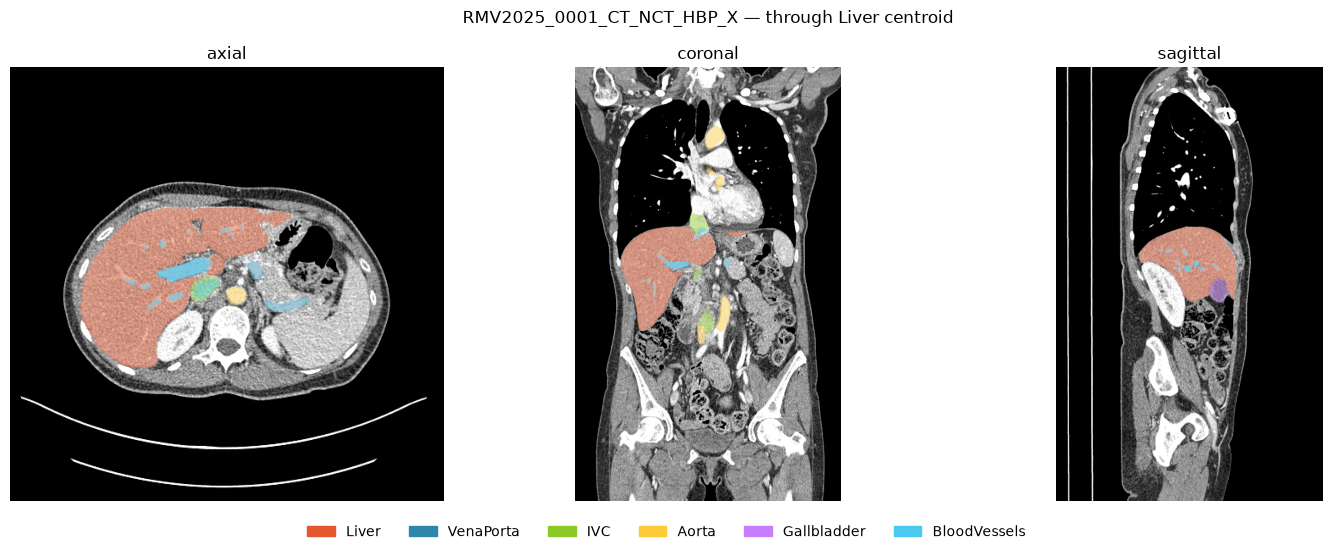

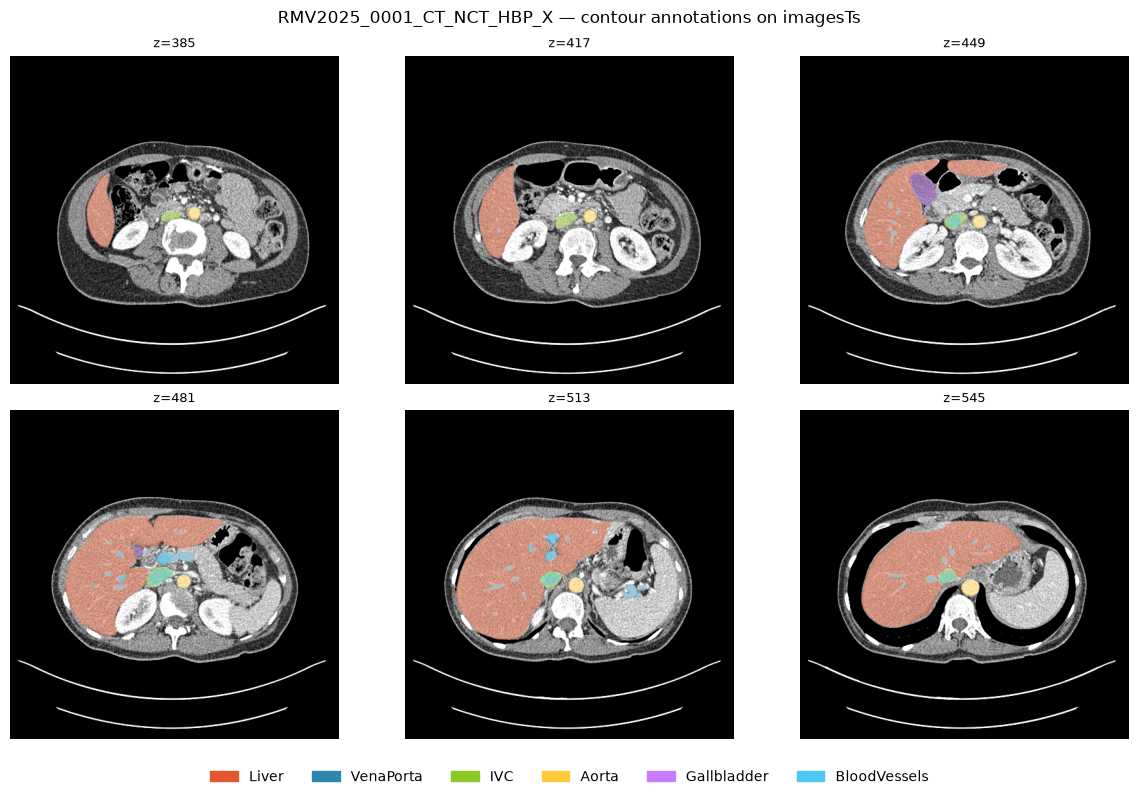

In [22]:
# --- Visual check: annotations over the base CT -------------------------------
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch

CLASS_COLORS = {"classLiver": "#e4572e", "classVenaPorta": "#2e86ab",
                "classIVC": "#8ac926", "classAorta": "#ffca3a",
                "classGallbladder": "#c77dff", "classBloodVessels": "#4cc9f0"}
CT_WINDOW = (-175, 250)          # configs/couinaud/swin_unetr.yaml:72


def _tint(mask, color, alpha=0.45):
    r, g, b = to_rgb(color)
    rgba = np.zeros(mask.shape + (4,))
    rgba[..., 0], rgba[..., 1], rgba[..., 2] = r, g, b
    rgba[..., 3] = mask * alpha
    return rgba


def _legend(fig, masks):
    fig.legend(handles=[Patch(color=c, label=k.replace("class", ""))
                        for k, c in CLASS_COLORS.items() if k in masks],
               loc="lower center", ncol=len(masks), frameon=False)


def overlay_axial(case, masks=None, ct=None, n=6, ref="classLiver"):
    """n axial slices spanning `ref`'s extent, every class tinted over the CT."""
    if masks is None:
        masks, _, _ = contours_to_mask(case)
    if ct is None:
        ct = nib.load(IMAGES / f"{case}.nii.gz").get_fdata()
    zs_nz = np.where(masks[ref].any(axis=(0, 1)))[0]
    zs = np.linspace(zs_nz[0], zs_nz[-1], n + 2).astype(int)[1:-1]

    cols = (n + 1) // 2
    fig, axes = plt.subplots(2, cols, figsize=(4 * cols, 8))
    for ax, z in zip(axes.ravel(), zs):
        ax.imshow(np.rot90(ct[:, :, z]), cmap="gray", vmin=CT_WINDOW[0], vmax=CT_WINDOW[1])
        for cls, m in masks.items():
            s = np.rot90(m[:, :, z])
            if s.any():
                ax.imshow(_tint(s, CLASS_COLORS.get(cls, "#ffffff")))
        ax.set_title(f"z={z}", fontsize=9)
    for ax in axes.ravel():
        ax.axis("off")
    _legend(fig, masks)
    fig.suptitle(f"{case} — contour annotations on imagesTs")
    fig.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


def overlay_ortho(case, masks=None, ct=None, affine=None, ref="classLiver"):
    """Axial / coronal / sagittal through `ref`'s centroid, aspect-corrected."""
    if masks is None:
        masks, affine, _ = contours_to_mask(case)
    im = nib.load(IMAGES / f"{case}.nii.gz")
    ct = im.get_fdata() if ct is None else ct
    affine = im.affine if affine is None else affine

    cx, cy, cz = np.argwhere(masks[ref]).mean(0).astype(int)
    sx, sy, sz = nib.affines.voxel_sizes(affine)
    views = [("axial", lambda v: np.rot90(v[:, :, cz]), sy / sx),
             ("coronal", lambda v: np.rot90(v[:, cy, :]), sz / sx),
             ("sagittal", lambda v: np.rot90(v[cx, :, :]), sz / sy)]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))
    for ax, (name, take, aspect) in zip(axes, views):
        ax.imshow(take(ct), cmap="gray", vmin=CT_WINDOW[0], vmax=CT_WINDOW[1], aspect=aspect)
        for cls, m in masks.items():
            s = take(m)
            if s.any():
                ax.imshow(_tint(s, CLASS_COLORS.get(cls, "#ffffff")), aspect=aspect)
        ax.set_title(name)
        ax.axis("off")
    _legend(fig, masks)
    fig.suptitle(f"{case} — through {ref.replace('class', '')} centroid")
    fig.tight_layout(rect=[0, 0.06, 1, 1])
    plt.show()


overlay_ortho(cases[0], masks, affine=affine)
overlay_axial(cases[0], masks)

In [23]:
# --- ICP mesh-to-contour registration -------------------------------------------
# Test if the transformation from GLB mesh space to CT space is consistent.
# If the transformation is the same for all cases, we can infer it from
# cornerstone contours and apply it to all meshes.

from scipy.spatial import cKDTree


def get_mesh_surface_points(case, cls="Liver", subset="full_model", sample_count=5000):
    """Sample points uniformly from GLB mesh surface."""
    mesh = load_mesh(GLB_ROOT / case / subset / f"class{cls}.glb")
    pts, _ = trimesh.sample.sample_surface(mesh, sample_count)
    return pts


def get_contour_surface_points(case, cls="classLiver"):
    """Extract surface voxels from rasterized contours (in world RAS coords)."""
    from scipy import ndimage

    # Rasterize to mask
    masks, aff, _ = contours_to_mask(case, interpolate=False)
    if cls not in masks:
        return np.array([]).reshape(0, 3)

    vol = masks[cls]
    if not vol.any():
        return np.array([]).reshape(0, 3)

    # Extract boundary: voxels on the surface
    eroded = ndimage.binary_erosion(vol)
    boundary = vol & ~eroded

    # Voxel coords -> world coords
    pts_voxel = np.argwhere(boundary).astype(float)
    pts_world = nib.affines.apply_affine(aff, pts_voxel)
    return pts_world


def _icp_numpy(src, dst, max_iter=50, tol=1e-6):
    """Rigid ICP: find R, t to minimize ||R @ src.T + t - dst||^2

    Returns (R, t, rmse) where rmse is the final root mean squared error.
    """
    src = np.asarray(src, dtype=np.float64)
    dst = np.asarray(dst, dtype=np.float64)

    R = np.eye(3)
    t = np.zeros(3)
    prev_error = np.inf

    for iteration in range(max_iter):
        # Transform source
        src_t = (R @ src.T + t[:, None]).T

        # Find nearest neighbors
        tree = cKDTree(dst)
        dists, idx = tree.query(src_t, k=1)
        error = np.sqrt(np.mean(dists ** 2))

        # Check convergence
        if abs(prev_error - error) < tol:
            break
        prev_error = error

        # Compute optimal R, t via SVD
        src_c = src_t - src_t.mean(axis=0, keepdims=True)
        dst_c = dst[idx] - dst[idx].mean(axis=0, keepdims=True)

        H = src_c.T @ dst_c
        U, _, Vt = np.linalg.svd(H)
        R_new = Vt.T @ U.T

        # Ensure proper rotation (det = 1)
        if np.linalg.det(R_new) < 0:
            Vt[-1, :] *= -1
            R_new = Vt.T @ U.T

        t_new = dst[idx].mean(axis=0) - (R_new @ src_t.mean(axis=0))
        R = R_new @ R
        t = R_new @ t + t_new

    # Final RMSE
    src_final = (R @ src.T + t[:, None]).T
    rmse = np.sqrt(np.mean(np.sum((src_final - dst) ** 2, axis=1)))

    return R, t, rmse


def test_mesh_to_contour_registration(test_cases=None, sample_count=5000):
    """Register mesh surfaces to contour surfaces for each case and class.

    Returns dict: case -> {class: {R, t, rmse, n_mesh, n_contour}}
    """
    UNIVERSAL = ["Liver", "VenaPorta", "IVC", "Aorta", "Gallbladder", "BloodVessels"]

    if test_cases is None:
        test_cases = cases[:5]

    results = {}
    print(f"Testing mesh registration on {len(test_cases)} cases, {sample_count} sample points")
    print(f"{'case':35s} {'class':20s} {'n_mesh':>7s} {'n_cont':>7s} {'RMSE [mm]':>12s} {'status'}")
    print("-" * 100)

    for case in test_cases:
        case_result = {}

        for cls in UNIVERSAL:
            cls_mesh = cls
            cls_cont = f"class{cls}"

            try:
                mesh_pts = get_mesh_surface_points(case, cls_mesh, sample_count=sample_count)
                cont_pts = get_contour_surface_points(case, cls_cont)

                if len(cont_pts) < 10:
                    status = f"sparse ({len(cont_pts)} pts)"
                    case_result[cls] = {"status": status}
                    print(f"{case:35s} {cls:20s} {len(mesh_pts):7d} {len(cont_pts):7d} {'—':>12s} {status}")
                    continue

                R, t, rmse = _icp_numpy(mesh_pts, cont_pts)

                case_result[cls] = {
                    "R": R.tolist(),
                    "t": t.tolist(),
                    "rmse": float(rmse),
                    "n_mesh": len(mesh_pts),
                    "n_contour": len(cont_pts),
                }

                status = "✓" if rmse < 50 else f"⚠️ RMSE={rmse:.1f}"
                print(f"{case:35s} {cls:20s} {len(mesh_pts):7d} {len(cont_pts):7d} {rmse:12.2f} {status}")

            except Exception as e:
                status = f"ERROR: {str(e)[:35]}"
                case_result[cls] = {"status": status}
                print(f"{case:35s} {cls:20s} {'—':>7s} {'—':>7s} {'—':>12s} {status}")

        results[case] = case_result

    # Analyze consistency
    print("\n" + "=" * 100)
    print("CONSISTENCY ANALYSIS")
    print("=" * 100)

    for cls in UNIVERSAL:
        rmses = []
        Rs = []
        for r in results.values():
            if cls in r and "rmse" in r[cls]:
                rmses.append(r[cls]["rmse"])
                Rs.append(np.array(r[cls]["R"]))

        if rmses:
            rmses = np.array(rmses)
            print(f"\n{cls}:")
            print(f"  RMSE:  mean {rmses.mean():.2f} mm, std {rmses.std():.2f}, "
                  f"range [{rmses.min():.2f}, {rmses.max():.2f}]")

            if Rs:
                R_mean = np.mean(Rs, axis=0)
                R_dev = np.mean([np.linalg.norm(R - R_mean) for R in Rs])
                R_frob = np.mean([np.linalg.norm(R - np.eye(3)) for R in Rs])
                print(f"  Rotation: avg deviation from mean {R_dev:.4f}, "
                      f"avg Frobenius from identity {R_frob:.4f}")
                print(f"  Mean R:\n{np.round(R_mean, 4)}")

    return results


# Test on first 5 cases
# results = test_mesh_to_contour_registration(test_cases=cases[:5])

In [24]:
# # --- Build Couinaud hybrid: cornerstone + mesh sectors ---------------------------
# # Keep 6 cornerstone classes, add 3 sector splits from GLB meshes.
# # Each sector is rasterized and intersected with liver.

# from scipy.ndimage import binary_dilation

# COUINAUD_OUT = ROOT / "couinaud_hybrid"


# def mesh_to_mask_sdf_simple(mesh, affine, shape):
#     """Rasterize mesh by ray-casting containment check."""
#     # Grid of voxel centers
#     coords_ijk = np.stack(np.meshgrid(
#         np.arange(shape[0]), np.arange(shape[1]), np.arange(shape[2]),
#         indexing='ij'
#     ), axis=-1).reshape(-1, 3).astype(np.float64)

#     # Transform to world coords
#     world_pts = nib.affines.apply_affine(affine, coords_ijk)

#     # Check containment
#     inside = mesh.contains(world_pts)
#     mask = inside.reshape(shape)

#     # Dilate boundary to catch edge voxels
#     mask = binary_dilation(mask, iterations=1)
#     return mask


# def build_couinaud_case(case, out_dir=COUINAUD_OUT, verbose=True):
#     """Build Couinaud mask: 6 cornerstone + 3 sector splits."""
#     out_dir.mkdir(parents=True, exist_ok=True)

#     # Load cornerstone
#     masks_cs, affine = contours_to_mask(case, interpolate=False, verbose=False)
#     if "classLiver" not in masks_cs:
#         if verbose:
#             print(f"{case}  SKIP (no liver)")
#         return None

#     liver = masks_cs["classLiver"]
#     im = nib.load(IMAGES / f"{case}.nii.gz")
#     shape = im.shape

#     # Start result
#     result = dict(masks_cs)

#     # Sector class mapping
#     sectors = {
#         "PediculoPortalIzquierdo": "CouinaudLeft",
#         "PediculoPortalAnteriorDerecho": "CouinaudRightAnterior",
#         "PediculoPortalPosteriorDerecho": "CouinaudRightPosterior",
#     }

#     if verbose:
#         print(f"{case}  ({len(result)} cornerstone classes)")

#     for glb_name, out_name in sectors.items():
#         glb_path = GLB_ROOT / case / "full_model" / f"class{glb_name}.glb"

#         if not glb_path.exists():
#             continue

#         try:
#             mesh = load_mesh(glb_path)

#             # Rasterize and intersect with liver
#             sector_mask = mesh_to_mask_sdf_simple(mesh, affine, shape)
#             sector_mask = sector_mask & liver

#             result[f"class{out_name}"] = sector_mask

#             n_vox = int(sector_mask.sum())
#             pct = 100 * n_vox / max(int(liver.sum()), 1)
#             if verbose:
#                 print(f"    + {out_name:25s}  {n_vox:9d} vox ({pct:5.1f}% of liver)")

#         except Exception as e:
#             if verbose:
#                 print(f"    ✗ {glb_name:25s}  {str(e)[:40]}")

#     # Write outputs
#     case_dir = out_dir / case
#     case_dir.mkdir(parents=True, exist_ok=True)

#     for cls, vol in result.items():
#         nib.save(nib.Nifti1Image(vol.astype(np.uint8), affine),
#                  case_dir / f"{cls}.nii.gz")

#     return len(result)


# # Build all cases
# print(f"Building Couinaud hybrid masks")
# print(f"Output: {COUINAUD_OUT}\n")

# results = {}
# for i, case in enumerate(cases, 1):
#     try:
#         n = build_couinaud_case(case, verbose=(i <= 3 or i % 10 == 0))
#         if n:
#             results[case] = {"classes": n, "status": "ok"}
#     except Exception as e:
#         results[case] = {"status": f"error: {str(e)[:40]}"}

# ok = sum(1 for r in results.values() if r["status"] == "ok")
# print(f"\nBuilt {ok}/{len(results)} cases")
# print(f"Output directory: {COUINAUD_OUT}")

Cornerstone mask classes (15 total):
   1: Liver
   2: VenaPorta
   3: IVC
   4: Aorta
   5: Gallbladder
   6: BloodVessels
   7: VenaHepaticaDerecha
   8: VenaHepaticaMedia
   9: VenaHepaticaIzquierda
  10: ArteriaHepatica
  11: ViaBiliar
  12: PediculoPortalDerecho
  13: PediculoPortalIzquierdo
  14: PediculoPortalAnteriorDerecho
  15: PediculoPortalPosteriorDerecho

RMV2025_0001_CT_NCT_HBP_X
  Shape match: True (512, 512, 910) vs (512, 512, 910)
  Affine match: True


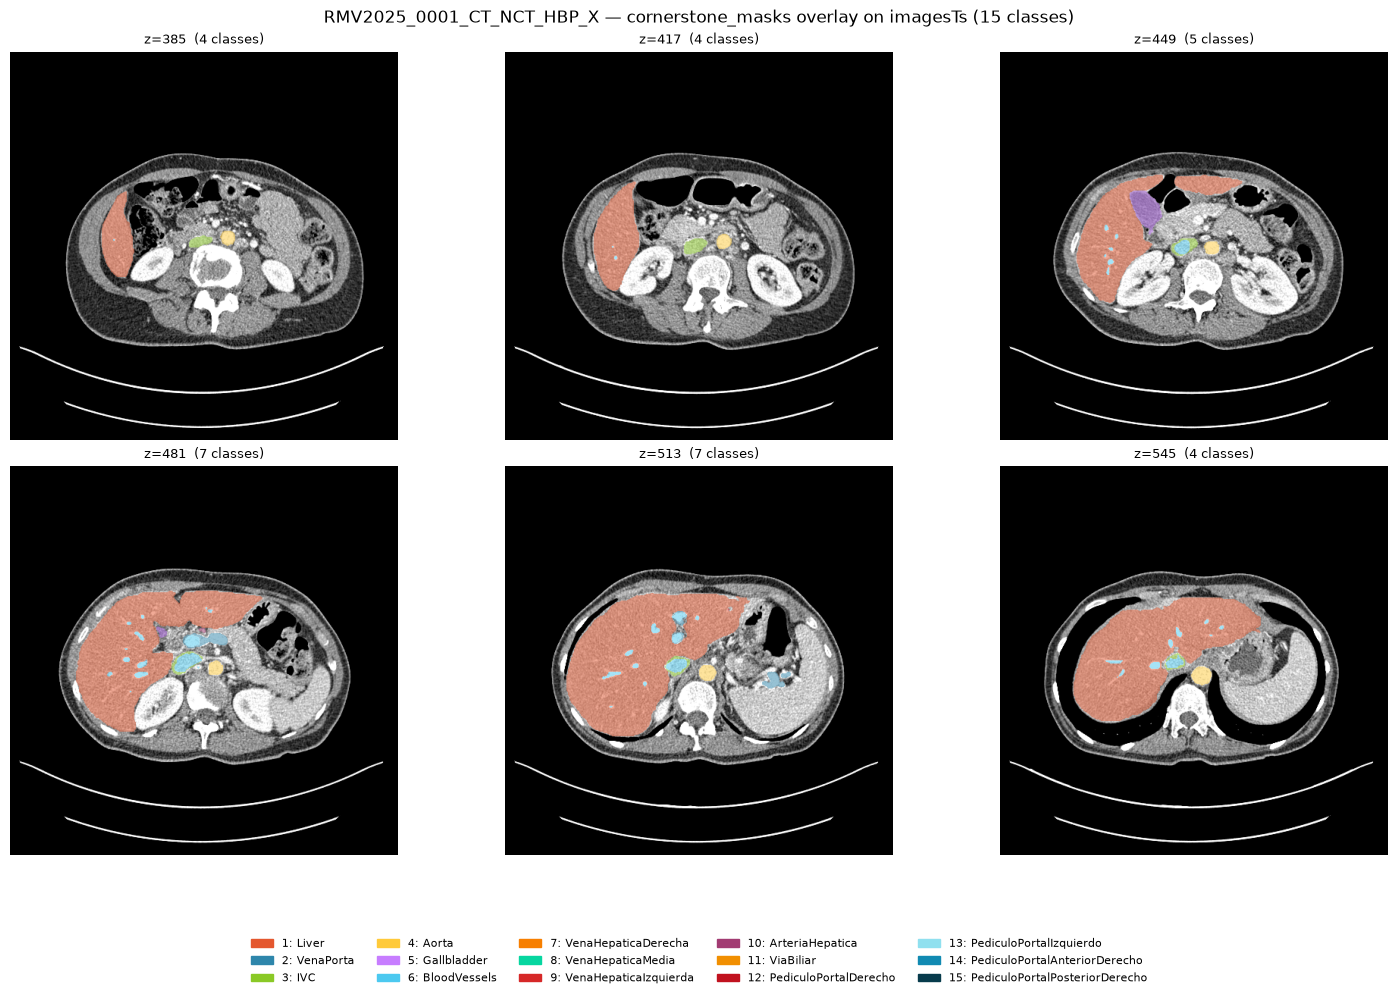

In [43]:
# --- Cornerstone masks visualization: verify correctness on CT images -------
# Load pre-computed label masks from data/cornerstone_masks/ and overlay on CT

CORNERSTONE_MASKS = ROOT / "cornerstone_masks"

# Load class label mapping
mask_labels = json.loads((CORNERSTONE_MASKS / "labels.json").read_text())
print(f"Cornerstone mask classes ({len(mask_labels)} total):")
for name, label_id in sorted(mask_labels.items(), key=lambda x: x[1]):
    print(f"  {label_id:2d}: {name.replace('class', '')}")
print()


def load_cornerstone_mask(case):
    """Load multi-class label map from cornerstone_masks."""
    path = CORNERSTONE_MASKS / f"{case}_mask.nii.gz"
    if not path.exists():
        return None, None
    img = nib.load(path)
    return img.get_fdata(), img.affine


# Create dynamic color palette for all classes using distinct colors
_class_colors_palette = {
    1: "#e4572e",    # Liver - red
    2: "#2e86ab",    # VenaPorta - blue
    3: "#8ac926",    # IVC - green
    4: "#ffca3a",    # Aorta - yellow
    5: "#c77dff",    # Gallbladder - purple
    6: "#4cc9f0",    # BloodVessels - cyan
    7: "#f77f00",    # VenaHepaticaDerecha - orange
    8: "#06d6a0",    # VenaHepaticaMedia - teal
    9: "#d62828",    # VenaHepaticaIzquierda - dark red
    10: "#a23b72",   # ArteriaHepatica - magenta
    11: "#f18f01",   # ViaBiliar - burnt orange
    12: "#c1121f",   # PediculoPortalDerecho - crimson
    13: "#90e0ef",   # PediculoPortalIzquierdo - light blue
    14: "#118ab2",   # PediculoPortalAnteriorDerecho - teal blue
    15: "#073b4c",   # PediculoPortalPosteriorDerecho - dark teal
}


def overlay_cornerstone_mask(case, n=6, window=(-175, 250)):
    """Overlay cornerstone label map on CT, n slices spanning liver extent."""
    ct, ct_affine = load_volume(IMAGES, case)
    mask_data, mask_affine = load_cornerstone_mask(case)
    
    if mask_data is None:
        print(f"No cornerstone mask for {case}")
        return
    
    # Check alignment
    shape_match = ct.shape == mask_data.shape
    affine_match = np.allclose(ct_affine, mask_affine)
    print(f"{case}")
    print(f"  Shape match: {shape_match} {ct.shape} vs {mask_data.shape}")
    print(f"  Affine match: {affine_match}")
    
    # Find liver (class 1) z-extent
    liver_mask = mask_data == 1  # classLiver is always 1
    zs_nz = np.where(liver_mask.any(axis=(0, 1)))[0]
    
    if len(zs_nz) == 0:
        print(f"  No liver found in mask")
        return
    
    zs = np.linspace(zs_nz[0], zs_nz[-1], n + 2).astype(int)[1:-1]
    
    cols = (n + 1) // 2
    fig, axes = plt.subplots(2, cols, figsize=(5 * cols, 10))
    for ax, z in zip(axes.ravel(), zs):
        # Base CT
        ax.imshow(np.rot90(ct[:, :, z]), cmap="gray", vmin=window[0], vmax=window[1])
        
        # Overlay each class
        mask_slice = np.rot90(mask_data[:, :, z].astype(int))
        for class_id, color in _class_colors_palette.items():
            class_mask = (mask_slice == class_id)
            if class_mask.any():
                tinted = _tint(class_mask, color, alpha=0.5)
                ax.imshow(tinted)
        
        # Report classes present at this slice
        classes_here = np.unique(mask_data[:, :, z])
        classes_here = classes_here[classes_here > 0]
        n_classes = len(classes_here)
        ax.set_title(f"z={z}  ({n_classes} classes)", fontsize=9)
    
    for ax in axes.ravel():
        ax.axis("off")
    
    # Legend with all classes
    from matplotlib.patches import Patch
    legend_items = []
    for label_name, class_id in sorted(mask_labels.items(), key=lambda x: x[1]):
        color = _class_colors_palette.get(class_id, "#999999")
        legend_items.append(Patch(color=color, label=f"{class_id}: {label_name.replace('class', '')}"))
    
    fig.legend(handles=legend_items, loc="lower center", ncol=5, frameon=False, fontsize=8)
    
    fig.suptitle(f"{case} — cornerstone_masks overlay on imagesTs ({len(mask_labels)} classes)")
    fig.tight_layout(rect=[0, 0.12, 1, 1])
    plt.show()


# Visualize first case
overlay_cornerstone_mask(cases[0])

In [44]:
# Quick QA check: scan all cases for shape/affine mismatches and class coverage
def qa_cornerstone_masks():
    """Check all cornerstone masks for correctness (shape, affine, class coverage)."""
    print(f"{'case':35s} {'shape_ok':>8s} {'affine_ok':>10s} {'classes':>8s} {'issue'}")
    print("-" * 80)
    
    issues = []
    class_counts = {}
    
    for case in cases:
        ct, ct_aff = load_volume(IMAGES, case)
        mask_data, mask_aff = load_cornerstone_mask(case)
        
        if mask_data is None:
            print(f"{case:35s} {'MISSING':>8s}")
            issues.append((case, "missing"))
            continue
        
        shape_ok = ct.shape == mask_data.shape
        affine_ok = np.allclose(ct_aff, mask_aff)
        
        classes_here = np.unique(mask_data)
        classes_here = classes_here[classes_here > 0]
        
        # Track class distribution
        for c in classes_here:
            class_counts[int(c)] = class_counts.get(int(c), 0) + 1
        
        issue = ""
        if not shape_ok:
            issue = f"SHAPE: {ct.shape} vs {mask_data.shape}"
            issues.append((case, issue))
        if not affine_ok:
            if issue:
                issue += "; "
            issue += "AFFINE mismatch"
            issues.append((case, issue))
        
        status = "✓" if (shape_ok and affine_ok) else "✗"
        print(f"{case:35s} {str(shape_ok):>8s} {str(affine_ok):>10s} "
              f"{len(classes_here):>8d} {issue}")
    
    print(f"\nSummary: {len(cases) - len(issues)}/{len(cases)} cases OK")
    
    # Class coverage across all cases
    print(f"\nClass coverage ({len(mask_labels)} total classes):")
    for label_name, class_id in sorted(mask_labels.items(), key=lambda x: x[1]):
        count = class_counts.get(class_id, 0)
        pct = 100 * count / len(cases)
        print(f"  {class_id:2d}: {label_name:35s} {count:2d}/{len(cases)} cases ({pct:5.1f}%)")
    
    if issues:
        print("\nIssues found:")
        for case, issue in issues:
            print(f"  {case:35s} {issue}")
    
    return issues, class_counts


issues, class_counts = qa_cornerstone_masks()

case                                shape_ok  affine_ok  classes issue
--------------------------------------------------------------------------------
RMV2025_0001_CT_NCT_HBP_X               True       True       15 
RMV2025_0002_MR_NCT_ARP_N               True       True       14 
RMV2025_0003_CT_UTV_VEP_P               True       True       15 
RMV2025_0004_CT_UTV_VEP_N               True       True       12 
RMV2025_0005_CT_UTV_VEP_L               True       True       11 
RMV2025_0006_CT_UTV_VEP_J               True       True       11 
RMV2025_0007_CT_UTV_VEP_H               True       True       12 
RMV2025_0008_CT_UTV_VEP_F               True       True       12 
RMV2025_0009_CT_UTV_VEP_D               True       True       12 
RMV2025_0010_CT_UTV_VEP_U               True       True       14 
RMV2025_0011_CT_UTV_VEP_S               True       True       14 
RMV2025_0012_CT_UTV_VEP_Q               True       True       13 
RMV2025_0013_CT_UTV_VEP_O               True       True 